In [1]:
import pandas as pd 

df = pd.read_csv('./final_engineered_ds.csv')
df.head()

,GGBS_kg_m3,GGBS_CaO_%,GGBS_SiO2_%,GGBS_Al2O3_%,GGBS_MgO_%,GGBS_Fe2O3_%,GGBS_SO3_%,FlyAsh_kg_m3,FA_CaO_%,FA_SiO2_%,...,CS 7 day (Mpa),CS 28 day (Mpa),Total_Binders,Total_SiO2,Total_CaO,Total_Al2O3,SiO2 / Al2O3,CaO / Al2O3,CaO / SiO2,Dim_Volume
0,0.0,47.75,27.17,8.6,3.89,0.42,1.45,650.0,15.48,48.43,...,34.0,29.00,650.0,48.43,15.480,17.150,2.823907,2.823907,0.319637,3375000.0
1,650.0,47.75,27.17,8.6,3.89,0.42,1.45,0.0,15.48,48.43,...,34.0,40.00,650.0,27.17,47.750,8.600,3.159302,3.159302,1.757453,3375000.0
2,325.0,47.75,27.17,8.6,3.89,0.42,1.45,325.0,15.48,48.43,...,34.0,45.00,650.0,37.80,31.615,12.875,2.935922,2.935922,0.836376,3375000.0
3,0.0,47.75,27.17,8.6,3.89,0.42,1.45,637.0,15.48,48.43,...,34.0,48.00,637.0,48.43,15.480,17.150,2.823907,2.823907,0.319637,3375000.0
4,637.0,47.75,27.17,8.6,3.89,0.42,1.45,0.0,15.48,48.43,...,34.0,50.32,637.0,27.17,47.750,8.600,3.159302,3.159302,1.757453,3375000.0


In [5]:
len(df.keys())

44

In [4]:
feature_cols = df.drop(columns=['CS 7 day (Mpa)', 'CS 28 day (Mpa)']).keys()
len(feature_cols), feature_cols

(42,
 Index(['GGBS_kg_m3', 'GGBS_CaO_%', 'GGBS_SiO2_%', 'GGBS_Al2O3_%', 'GGBS_MgO_%',
        'GGBS_Fe2O3_%', 'GGBS_SO3_%', 'FlyAsh_kg_m3', 'FA_CaO_%', 'FA_SiO2_%',
        'FA_Al2O3_%', 'FA_MgO_%', 'FA_Fe2O3_%', 'FA_SO3_%', 'SF_kg_m3',
        'SF_CaO_%', 'SF_SiO2_%', 'SF_Al2O3_%', 'SF_MgO_%', 'SF_Fe2O3_%',
        'SF_SO3_%', 'Total NaOH (kg in 1m3 mix)', 'Concentration (M) NaOH',
        'Total Na2SiO3 (kg in 1m3 of mix)', 'Coarse Aggregate (kg/m3)',
        'Fine Aggregates (kg/m3)', 'Water (kg/m3)', 'Activator_Binder_Ratio',
        'Water_Binder_Ratio', 'Superplasticizer_%',
        'SiO2 to Na2O (silicate modulus)', 'Curing_Temperature',
        'Relative Humidity', 'Condition', 'Total_Binders', 'Total_SiO2',
        'Total_CaO', 'Total_Al2O3', 'SiO2 / Al2O3', 'CaO / Al2O3', 'CaO / SiO2',
        'Dim_Volume'],
       dtype='str'))

Total Features: 42


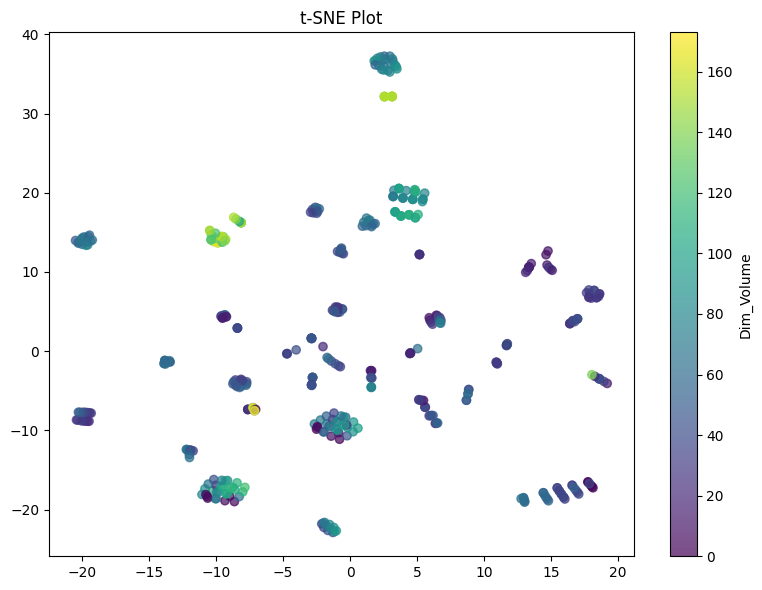

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np

df = pd.read_csv("./final_engineered_ds.csv").drop(columns=['CS 7 day (Mpa)'])
feature_cols = df.drop(columns=['CS 28 day (Mpa)']).keys()
X = df[feature_cols].values.astype(np.float32)
print(f'Total Features: {len(feature_cols)}')
y = df['CS 28 day (Mpa)'].values.astype(np.float32)

X_scaled = StandardScaler().fit_transform(X)
X_emb = TSNE(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=y, cmap="viridis", alpha=0.7)
plt.colorbar(sc, label=df.columns[-1])
plt.title("t-SNE Plot")
plt.tight_layout()
plt.savefig("tsne_plot.png", dpi=150)
plt.show()